<h1>Birthday problem</h1>

<p>There are $k$ people in a room. Assume each person’s birthday is equally likely to be any of the $365$ days of the year (we exclude February 29), and that people’s birthdays are independent (this means that knowing some people’s birthdays gives us no information about other people’s birthdays; this would not hold if, e.g., we knew that two of the people were twins). What is the probability that at least one pair of people in the group have the same birthday?</p>

<em>Solution:</em>
<p>There are $365^k$ ways to assign birthdays to the people in the room, since we can imagine the $365$ days of the year being sampled $k$ times, with replacement. By assumption, all of these possibilities are equally likely, so the naive definition of probability applies.</p>
<p>Used directly, the naive definition says we just need to count the number of ways to assign birthdays to $k$ people such that there are two people who share a birthday.
But this counting problem is hard, since it could be Emma and Steve who share a birthday, or Steve and Naomi, or all three of them, or the three of them could share a birthday while two others in the group share a different birthday, or various other possibilities.
</p>

<p>Instead, let’s count the complement: the number of ways to assign birthdays to $k$ people such that no two people share a birthday. This amounts to sampling the $365$ days of the year without replacement, so the number of possibilities is $365·364·363···(365−k+1)$ for $k ≤ 365$. Therefore the probability of no birthday matches in a group of $k$ people is</p>

$P(no\ birthday\ match) = \frac{365·364···(365−k+1)}{365^k}$

and the probability of at least one birthday match is

$P(at\ least\ 1\ birthday\ match) = 1 - \frac{365·364···(365−k+1)}{365^k}$

In [42]:
# Import libraries
import numpy as np

# User defined functions
def birthday_problem(k):
    partial_result = 365
    if k > 1:
        for i in range(1, k):
            partial_result = (365-i)*partial_result
    numerator = partial_result
    denominator = 365**k
    return 1 - numerator/denominator

# K: array of k [k=1, k=2 ... k=100]
K = np.arange(1, 100+1)

# P: array of probabilities p for every k
vectorized = np.vectorize(birthday_problem)
P = vectorized(K)

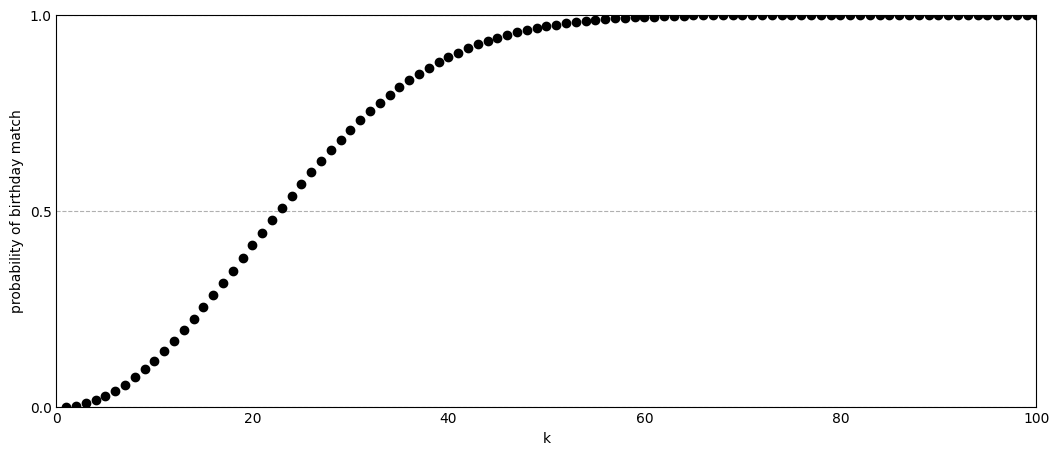

In [85]:
import matplotlib.pyplot as plt

plt.style.use('_mpl-gallery')
plt.rcParams["figure.figsize"] = (10,4)

# plot
fig, ax = plt.subplots()

ax.scatter(K, P, c='black')

ax.set(xlim=(0, 100), xticks=np.arange(0, 101, 20),
       ylim=(0, 1), yticks=np.arange(0, 1.1, 0.5))

ax.yaxis.grid(True, linestyle='--')
ax.xaxis.grid(False)

ax.set_xlabel(xlabel="k")
ax.set_ylabel(ylabel="probability of birthday match")

plt.show()

In [103]:
import plotly.express as px

fig = px.scatter(x=K, y=P)
fig.update_layout(
    xaxis_title="k",
    yaxis_title="probability of birthday match",
    template="plotly_white")
fig.update_traces(marker_color="black")
fig.show()